# Demo NLP Chương 5: Embeddings (Biểu diễn Ngữ nghĩa Vector)

Minh họa các khái niệm chính trong Chương 5:
1. Ma trận đếm đồng xuất hiện (Simple Count-based Embeddings) & Cosine Similarity
2. Huấn luyện Dense Embeddings với thuật toán Word2Vec (Skip-gram)
3. Các thuộc tính ngữ nghĩa (Từ đồng nghĩa, Phép loại suy - Analogy)
4. Trực quan hóa Embeddings bằng t-SNE
5. Thiên vị trong Embeddings (Bias in Embeddings)

In [1]:
!pip install pandas numpy nltk gensim scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
import warnings
warnings.filterwarnings('ignore')

# Tải gói ngôn ngữ cho NLTK
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 0. Tải và Tiền xử lý Dữ liệu

In [3]:

try:
    df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
    # Lấy 10,000 dòng để demo chạy nhanh hơn
    df = df.sample(10000, random_state=42).reset_index(drop=True)
    print("Dữ liệu đã tải thành công! Kích thước:", df.shape)
except FileNotFoundError:
    print("Vui lòng tải file IMDB Dataset.csv từ Kaggle và đặt vào thư mục làm việc.")
    # Tạo dummy data để code vẫn chạy được nếu chưa tải file
    df = pd.DataFrame({'review':["This movie is great, an absolute masterpiece.", 
                                  "Terrible film, bad acting and awful plot.",
                                  "The director did a wonderful job with this cinema."]})

# Tiền xử lý văn bản cơ bản
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower() # Viết thường
    text = re.sub(r'<.*?>', '', text) # Xóa thẻ HTML (đặc thù IMDB)
    text = re.sub(r'[^a-z\s]', '', text) # Xóa dấu câu
    tokens = word_tokenize(text)
    # Xóa stop words
    tokens =[word for word in tokens if word not in stop_words and len(word) > 1]
    return tokens

print("Đang tiền xử lý dữ liệu...")
df['tokens'] = df['review'].apply(preprocess_text)
sentences = df['tokens'].tolist()
print("Tiền xử lý hoàn tất! Ví dụ dòng đầu tiên:")
print(sentences[0][:10])

Dữ liệu đã tải thành công! Kích thước: (10000, 2)
Đang tiền xử lý dữ liệu...
Tiền xử lý hoàn tất! Ví dụ dòng đầu tiên:
['really', 'liked', 'summerslam', 'due', 'look', 'arena', 'curtains', 'look', 'overall', 'interesting']


## 1. Simple Count-based Embeddings & Cosine Similarity 

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Demo với một mini-corpus giống trong sách để dễ hiểu
mini_corpus =[
    "is traditionally followed by cherry pie, a traditional dessert",
    "often mixed, such as strawberry rhubarb pie. Apple pie",
    "computer peripherals and personal digital assistants. These devices usually",
    "a computer. This includes information available on the internet"
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(mini_corpus)

# Ma trận word-context (Term-Document Matrix cho đơn giản)
vocab = vectorizer.get_feature_names_out()
word_vectors_sparse = X.toarray()

# Tạo dataframe để hiển thị (Giống Figure 5.3 trong sách)
sparse_df = pd.DataFrame(word_vectors_sparse, columns=vocab, index=['cherry_doc', 'strawberry_doc', 'digital_doc', 'info_doc'])
print("Ma trận Count-based Vectors (Sparse):\n")
display(sparse_df[['pie', 'computer', 'information']])

# Tính Cosine Similarity giữa câu chứa 'digital' và 'information'
# Trong sách: thông tin (information) gần với kỹ thuật số (digital) hơn là quả anh đào (cherry)
cos_sim_digital_info = cosine_similarity(X[2], X[3])[0][0]
cos_sim_cherry_info = cosine_similarity(X[0], X[3])[0][0]

print(f"\nCosine Similarity (Digital doc vs Info doc): {cos_sim_digital_info:.3f}")
print(f"Cosine Similarity (Cherry doc vs Info doc): {cos_sim_cherry_info:.3f}")

Ma trận Count-based Vectors (Sparse):



,pie,computer,information
cherry_doc,1,0,0
strawberry_doc,2,0,0
digital_doc,0,1,0
info_doc,0,1,1



Cosine Similarity (Digital doc vs Info doc): 0.118
Cosine Similarity (Cherry doc vs Info doc): 0.000


## 2. Word2Vec: Skip-gram Embeddings 
Sparse vectors có nhược điểm là kích thước quá lớn và chứa toàn số 0. 
Dùng thư viện `Gensim` để huấn luyện mô hình **Word2Vec (với thuật toán Skip-gram, sg=1)** tạo ra các **Dense Embeddings** ngắn và dày đặc hơn (thường có kích thước từ 50-300 chiều).

In [5]:
from gensim.models import Word2Vec

# Huấn luyện mô hình Word2Vec với thuật toán Skip-gram (sg=1)
# window = 5 (cửa sổ ngữ cảnh 5 từ trái/phải)
# vector_size = 100 (kích thước vector d=100)
print("Đang huấn luyện mô hình Word2Vec (Skip-gram)...")
w2v_model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=5, sg=1, workers=4, epochs=5)
print("Huấn luyện xong!")

# Lấy vector của từ 'movie'
word_vector_movie = w2v_model.wv['movie']
print(f"\nKích thước vector của từ 'movie': {word_vector_movie.shape}")
print(f"10 giá trị đầu tiên của vector 'movie':\n{word_vector_movie[:10]}")

Đang huấn luyện mô hình Word2Vec (Skip-gram)...
Huấn luyện xong!

Kích thước vector của từ 'movie': (100,)
10 giá trị đầu tiên của vector 'movie':
[-0.03524024  0.01512273  0.09792365  0.10355752 -0.12627614 -0.37664586
  0.30868223  0.53123677 -0.36534256 -0.10601992]


## 3. Các thuộc tính ngữ nghĩa
Khám phá sự tương đồng từ (Word Similarity) và Mô hình Hình bình hành (Parallelogram model cho Phép loại suy - Analogy).

In [6]:
# 1. Tìm các từ đồng nghĩa / tương đồng nhất (First-order & Second-order co-occurrence)
target_word = 'director'
print(f"10 từ tương đồng nhất với '{target_word}':")
for word, score in w2v_model.wv.most_similar(target_word, topn=10):
    print(f"- {word}: {score:.4f}")

print("\n--------------------------\n")
target_word_2 = 'awful'
print(f"10 từ tương đồng nhất với '{target_word_2}':")
for word, score in w2v_model.wv.most_similar(target_word_2, topn=10):
    print(f"- {word}: {score:.4f}")

10 từ tương đồng nhất với 'director':
- writerdirector: 0.7327
- directors: 0.6972
- producer: 0.6900
- screenwriter: 0.6744
- filmmaker: 0.6724
- verhoeven: 0.6700
- soderbergh: 0.6659
- producers: 0.6653
- altman: 0.6520
- proved: 0.6444

--------------------------

10 từ tương đồng nhất với 'awful':
- atrocious: 0.8461
- horrible: 0.8244
- terrible: 0.8240
- abysmal: 0.8068
- horrendous: 0.8049
- pathetic: 0.7938
- dreadful: 0.7935
- lousy: 0.7790
- horrid: 0.7719
- sucks: 0.7692


### Phép loại suy (Analogy)


In [7]:
# Thử nghiệm trên mô hình IMDB của chúng ta:
# bad is to terrible as good is to ... ? (terrible - bad + good)
print("Phép loại suy trên IMDB: terrible - bad + good = ?")
result = w2v_model.wv.most_similar(positive=['terrible', 'good'], negative=['bad'], topn=3)
for word, score in result:
    print(f"- {word}: {score:.4f}")

print("\n--- Tải Pre-trained Embeddings (GloVe) để xem ví dụ kinh điển trong sách ---")
import gensim.downloader as api
# Tải bộ GloVe (có thể mất 1-2 phút, dung lượng ~100MB)
glove_model = api.load("glove-wiki-gigaword-100")

# Ví dụ trong sách: king - man + woman = queen
print("\nPhép loại suy kinh điển (GloVe): king - man + woman = ?")
analogy_result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=1)
print(f"=> Kết quả: {analogy_result[0][0]} (Độ tương đồng: {analogy_result[0][1]:.4f})")

# Paris - France + Italy = Rome
print("\nPhép loại suy thủ đô (GloVe): paris - france + italy = ?")
analogy_result_2 = glove_model.most_similar(positive=['paris', 'italy'], negative=['france'], topn=1)
print(f"=> Kết quả: {analogy_result_2[0][0]} (Độ tương đồng: {analogy_result_2[0][1]:.4f})")

Phép loại suy trên IMDB: terrible - bad + good = ?
- goodthe: 0.7164
- decent: 0.6936
- fabulous: 0.6931

--- Tải Pre-trained Embeddings (GloVe) để xem ví dụ kinh điển trong sách ---
[==================================================] 100.0% 128.1/128.1MB downloaded

Phép loại suy kinh điển (GloVe): king - man + woman = ?
=> Kết quả: queen (Độ tương đồng: 0.7699)

Phép loại suy thủ đô (GloVe): paris - france + italy = ?
=> Kết quả: rome (Độ tương đồng: 0.8190)


## 4. Trực quan hóa Embeddings bằng t-SNE
Tương tự Figure 5.1 trong sách, sử dụng t-SNE (t-Distributed Stochastic Neighbor Embedding) để giảm chiều vector từ 100 chiều xuống 2 chiều để vẽ đồ thị.

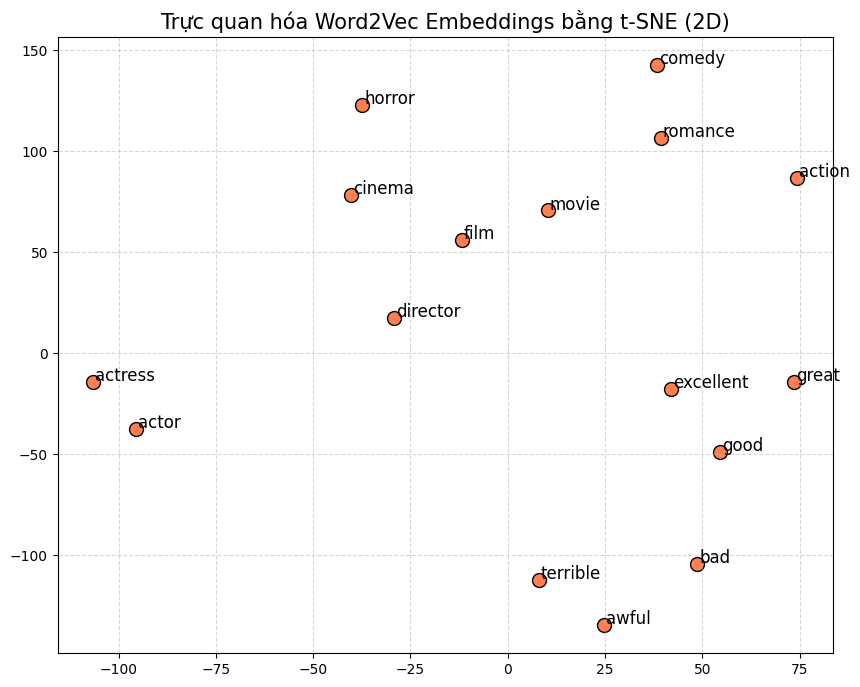

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Chọn ra một số từ để trực quan hóa
words_to_plot =['movie', 'film', 'cinema', 'director', 'actor', 'actress', 
                 'good', 'great', 'excellent', 'bad', 'terrible', 'awful',
                 'action', 'comedy', 'horror', 'romance']

# Lấy các vector tương ứng từ mô hình Word2Vec (IMDB)
word_vectors_plot = np.array([w2v_model.wv[word] for word in words_to_plot])

# Giảm chiều bằng t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vectors_2d = tsne.fit_transform(word_vectors_plot)

# Vẽ đồ thị
plt.figure(figsize=(10, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='coral', edgecolors='k', s=100)

for i, word in enumerate(words_to_plot):
    plt.annotate(word, (vectors_2d[i, 0] + 0.5, vectors_2d[i, 1] + 0.5), fontsize=12)

plt.title("Trực quan hóa Word2Vec Embeddings bằng t-SNE (2D)", fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 5. Thiên vị trong Embeddings 

In [9]:
print("Kiểm tra sự thiên vị giới tính nghề nghiệp trong GloVe Embeddings:")

# Bác sĩ nam -> Đàn ông. Vậy Phụ nữ -> Bác sĩ nữ hay Y tá?
# doctor - man + woman = ?
bias_result_1 = glove_model.most_similar(positive=['doctor', 'woman'], negative=['man'], topn=3)
print("\nBài toán: doctor - man + woman")
for word, score in bias_result_1:
    print(f"- {word} ({score:.4f})")

# Lập trình viên nam -> Đàn ông. Vậy Phụ nữ -> ?
# programmer - man + woman = ?
bias_result_2 = glove_model.most_similar(positive=['programmer', 'woman'], negative=['man'], topn=3)
print("\nBài toán: programmer - man + woman")
for word, score in bias_result_2:
    print(f"- {word} ({score:.4f})")

print("\nNhận xét: Hệ thống gán 'nurse' (y tá) hoặc các nghề mang tính định kiến thay vì chức danh chuyên môn tương đương. Điều này gây ra 'Allocational harm'.")

Kiểm tra sự thiên vị giới tính nghề nghiệp trong GloVe Embeddings:

Bài toán: doctor - man + woman
- nurse (0.7735)
- physician (0.7189)
- doctors (0.6824)

Bài toán: programmer - man + woman
- educator (0.5853)
- programmers (0.5731)
- linguist (0.5432)

Nhận xét: Hệ thống gán 'nurse' (y tá) hoặc các nghề mang tính định kiến thay vì chức danh chuyên môn tương đương. Điều này gây ra 'Allocational harm'.
